In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.integrate import odeint
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True
from scipy.integrate import solve_ivp

In [2]:
# Model parameters
N = 100000 # Total population in 2010
mu = 0#1/(70*365);  # Natural mortality rate per day
pi = 0#mu*N  # Birth rate per day
beta_0 = 0.0007 # Transmission rate
eps = 0.024 # 6 weeks #0.2     # Progression from E to I- 5 days
eta_0 = 1/15 #0.33 #0.0071  # baseline care seeking delay, 3 days
p = 0.8     # Proportion seeking L
k_l = 1/2  # The base screening delay at L, 2 days
k_h = 1  # The base diagnosis delay at H, 2 hours= 1/12 days
gamma_l = 0.6 #0.7      # Sensitivity of smear microscopy
q_h = 0.8      # Sensitivity of GeneXpert
alpha = 0.005  # Treatment recovery rate 1/180 
sigma = 0#1/(0.5*365) #0.03  # Immunity loss, after 18 months
phi = 1/30 #0.1   # Re-entry from F to I, assumed 1 month
phi2 = 1/90
mu_TB = 0.01 # # TB-specific mortality rate-> assumed
lamda = 0.9
xi = 0.7
max_T = 1
surges = 1
omega0 = 1
C_L = 100  # Capacity of L (tests/day) for two Smear microscopy
C_H = 16 #500   # Capacity of H (tests/day)
D_max = 15   # Maximum delay (days)
Diagnosis_D_max = 7 # maximum diagnosis delay, assumed 1 days
Screening_D_max = 7 # maximum screening delay, assumed 2 days

d1 = d2 = d3 = d4 = 0.001

# Initial conditions
I0 = 10   # Initial infected cases
S0 = N - I0
E0 = 0
L0 = 0
H0 = 0
T0 = 0
F0 = 0
R0 = 0
D0 = 0
New_cases0 = 0
New_treated = 0
state0 = [S0, E0, I0, L0, H0, T0, F0, R0, New_cases0, New_treated, D0]

# Time vector
t = np.linspace(0, max_T*365, max_T*365)  # 1 year

In [3]:
demand_amplitude = 1
def initial_delay_function(C, Q, D_max, theta=0.5):
    x = np.clip(theta * (C - Q), -500, 500)
    return D_max / (1 + np.exp(x))

def diagnosis_delay_function(C, Q, D_max_d, theta=0.5):
    x = np.clip(theta * (C - Q), -500, 500)
    return D_max_d / (1 + np.exp(x))

# Effective rate with delay
def effective_rate(base_rate, D):
    return base_rate / (1 + base_rate * D)

def beta_t(t, beta0, surges=1, demand_amplitude = 1):
    
    return beta0 * (1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/3))   

# TB model ODEs
def tb_model( t, state, params):
    
    S, E, I, L, H, T, F, R, New_cases, New_treated, D  = state
    
    NN = S + E + I + H + L + F + T + R + D
    
    
    
    eps, eta_0, p, gamma_l, k_h, k_l,  q_h, alpha, phi, mu_TB, C_L, C_H, omega0, D_max, Diagnosis_D_max, Screening_D_max, beta_0, lamda, xi, demand_amplitude, surges, d1, d2, d3 = params

    beta  = beta_0 #beta_t(t,  beta_0)

    FOI = beta*(I + xi*(H + L) + F + D)/(1+ lamda*(I + xi*(H + L) + F + D))

    omega = omega0* (p*eta_0 * I/NN) * (S + E + R)
    
    # Demands
    Q_L = p*eta_0 * I + omega #*(1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/2) )
    Q_H = (1 - p) * eta_0* I  + gamma_l *k_l* L #(1 + demand_amplitude * np.sin(2 * np.pi * surges  * t/365 - np.pi/2) )
    
    # Initial care seeking Delays
    D_L_initial = initial_delay_function(C_L, Q_L, D_max)
    D_H_initial = initial_delay_function(C_H, Q_H, D_max)

    #Screening/Diagnosis delay
    D_L_screeing = diagnosis_delay_function(C_L, Q_L, Screening_D_max)
    D_H_daignosis = diagnosis_delay_function(C_H, Q_H, Diagnosis_D_max)

    # initial patiend care-seeking delay rate
    eta_L = effective_rate(eta_0, D_L_initial)
    eta_H = effective_rate(eta_0, D_H_initial)
   

    #Screening/Diagnosis delay rate
    k_L = effective_rate(k_l, D_L_screeing)
    k_H =  effective_rate(k_h, D_H_daignosis)

    new_L = p * eta_L
    new_H = (1 - p) * eta_H 

    #L_to_H = k_L* (1 + demand_amplitude * np.sin(2 * np.pi * 3 * t/365 - np.pi/2))
    
    # ODEs
    dSdt = -FOI* S  
    dEdt = FOI * S  - eps* E
    dIdt = eps * E - (new_L + new_H ) * I + (1-d1)*phi * F + phi2*D - mu_TB * I 
    dLdt = new_L * I - (1-d2)*k_L * L -  mu_TB* L - d2*L
    dHdt = new_H * I + (1-d2)*k_L*gamma_l * L - (1-d3)*k_H * H - mu_TB * H - d3*H
    dTdt = (1-d3)*q_h * k_H * H - alpha * T
    dFdt = (1-d2)*(1 - gamma_l) * k_L * L + (1-d3)*(1 - q_h) * k_H * H - ((1-d1)*phi + mu_TB) * F - d1*F
    dRdt = alpha * T  
    dNewCases = FOI * S 
    dNewTreated = (1-d3)*q_h * k_H * H
    dDdt = d1*F + d2*L + d3* H - (phi2 + mu_TB)*D
    
    
    return [dSdt, dEdt, dIdt, dLdt, dHdt, dTdt, dFdt, dRdt, dNewCases, dNewTreated, dDdt]

In [4]:
# baseline values
eta_0_base = 1/15
k_l_base = 1/2
k_h_base = 1
C_L_base = 300
C_H_base = 64
base_param_tuple = (eps, eta_0_base, p, gamma_l, k_h_base, k_l_base, q_h, alpha, phi, mu_TB,
                       C_L_base, C_H_base, omega0, D_max, Diagnosis_D_max,
                       Screening_D_max, beta_0, lamda, xi, demand_amplitude,
                       surges, d1, d2, d3)
base_sol_final = solve_ivp(tb_model, [t[0], t[-1]], state0, method='LSODA',
                        t_eval=t, args=(base_param_tuple,), max_step=0.5, rtol=1e-6, atol=1e-8)
base_sol = base_sol_final.y[9,-1]

In [5]:
nn = 20



# parameter ranges
eta_0_values = np.linspace(1/30, 1/7, nn+1)   # patient delay (Y-axis)
C_L_values   = np.linspace(50, 300, nn+1)     # screening capacity
C_H_values   = np.linspace(8, 64, nn+1)       # diagnosis capacity
k_h_values   = np.linspace(1/7, 1, nn+1)      # diagnosis delay
k_l_values   = np.linspace(1/7, 1, nn+1)      # screening delay

# prepare grids for contour plots
X1, Y1 = np.meshgrid(C_L_values, eta_0_values)  # diagnosis delay vs patient delay 
X2, Y2 = np.meshgrid(C_L_values, k_h_values)  # diagnosis capacity vs patient delay

# storage for results
Z1 = np.zeros_like(X1)
Z2 = np.zeros_like(X2)

# loop over patient delay values
for i, eta_0 in enumerate(eta_0_values):
    
    for j, C_L in enumerate(C_L_values):
        
        param_tuple = (eps, eta_0, p, gamma_l, k_h_base, k_l_base, q_h, alpha, phi, mu_TB,
                       C_L, C_H_base, omega0, D_max, Diagnosis_D_max,
                       Screening_D_max, beta_0, lamda, xi, demand_amplitude,
                       surges, d1, d2, d3)
        sol = solve_ivp(tb_model, [t[0], t[-1]], state0, method='LSODA',
                        t_eval=t, args=(param_tuple,), max_step=0.5, rtol=1e-6, atol=1e-8)
        final_treated = sol.y[9, -1]
        change_treated = ((final_treated - base_sol)/base_sol)*100
        Z1[i, j] = change_treated #sol.y[9, -1]
for i, k_h in enumerate(k_h_values):
    
    for j, C_L in enumerate(C_L_values):
       
        param_tuple = (eps, eta_0_base, p, gamma_l, k_h, k_l_base, q_h, alpha, phi, mu_TB,
                       C_L_base, C_H_base, omega0, D_max, Diagnosis_D_max,
                       Screening_D_max, beta_0, lamda, xi, demand_amplitude,
                       surges, d1, d2, d3)
        sol = solve_ivp(tb_model, [t[0], t[-1]], state0, method='LSODA',
                        t_eval=t, args=(param_tuple,), max_step=0.5, rtol=1e-6, atol=1e-8)
        final_treated = sol.y[9, -1]
        change_treated = ((final_treated - base_sol)/base_sol)*100
        Z2[i, j] = change_treated #sol.y[9, -1]

In [6]:

def reciprocal_ticklabels(values):
    return [f"{1/v:.0f}" for v in values]

In [7]:
# fig, axs = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

# cont1 = axs[0].contourf(X1, Y1, Z1, levels=20, cmap="rainbow")

# axs[0].set_yticks(eta_0_values[::5])
# axs[0].set_yticklabels(reciprocal_ticklabels(eta_0_values[::5]))

# # invert to match desired orientation
# axs[0].invert_yaxis()  # x: 7 days (right) → 30 days (left)

# axs[0].set_title("(a)")
# axs[0].set_ylabel("Patient delay (days)")
# axs[0].set_xlabel("Screening capacity ")

# cont2 = axs[1].contourf(X2, Y2 ,Z2, levels=20, cmap="rainbow")

# axs[1].set_yticks(k_h_values[::4])
# axs[1].set_yticklabels(reciprocal_ticklabels(k_h_values[::4]))
# axs[1].invert_yaxis()  

# axs[1].set_xlabel("Screening capacity")

# axs[1].set_title("(b)")
# axs[1].set_ylabel("Diagnosis delay (days)")

# # shared colorbar
# cbar = fig.colorbar(cont2, ax=axs, orientation="vertical", shrink=0.8)
# cbar.set_label("Cumulative treated")

# plt.show()

In [8]:
# parameter ranges
eta_0_values = np.linspace(1/30, 1/7, nn+1)   # patient delay (Y-axis)
C_L_values   = np.linspace(50, 300, nn+1)     # screening capacity
C_H_values   = np.linspace(8, 64, nn+1)       # diagnosis capacity
# k_h_values   = np.linspace(1/7, 1, nn+1)      # diagnosis delay
# k_l_values   = np.linspace(1/7, 1, nn+1)      # screening delay


# prepare grids for contour plots
X3, Y3 = np.meshgrid(C_L_values, eta_0_values)  # diagnosis delay vs patient delay 
X4, Y4 = np.meshgrid(C_L_values, C_H_values)  # diagnosis capacity vs patient delay

# storage for results
Z3 = np.zeros_like(X3)
Z4 = np.zeros_like(X4)

# loop over patient delay values
for i, eta_0  in enumerate(eta_0_values):
    
    for j, C_L in enumerate(C_L_values):
        
        param_tuple = (eps, eta_0, p, gamma_l, k_h_base, k_l_base, q_h, alpha, phi, mu_TB,
                       C_L, C_H_base, omega0, D_max, Diagnosis_D_max,
                       Screening_D_max, beta_0, lamda, xi, demand_amplitude,
                       surges, d1, d2, d3)
        sol = solve_ivp(tb_model, [t[0], t[-1]], state0, method='LSODA',
                        t_eval=t, args=(param_tuple,), max_step=0.5, rtol=1e-6, atol=1e-8)
        change_treated = ((sol.y[9, -1]-base_sol)/base_sol)*100
        
        Z3[i, j] = change_treated #sol.y[9, -1]

for i, C_H in enumerate(C_H_values):
    
    for j, C_L in enumerate(C_L_values):
   
        param_tuple = (eps, eta_0_base, p, gamma_l, k_h_base, k_l_base, q_h, alpha, phi, mu_TB,
                       C_L, C_H, omega0, D_max, Diagnosis_D_max,
                       Screening_D_max, beta_0, lamda, xi, demand_amplitude,
                       surges, d1, d2, d3)
        sol = solve_ivp(tb_model, [t[0], t[-1]], state0, method='LSODA',
                        t_eval=t, args=(param_tuple,), max_step=0.5, rtol=1e-6, atol=1e-8)
        change_treated = ((sol.y[9, -1]-base_sol)/base_sol)*100
        Z4[i, j] = change_treated #sol.y[9, -1]

<>:29: SyntaxWarning: invalid escape sequence '\%'
<>:29: SyntaxWarning: invalid escape sequence '\%'
/var/folders/d0/77rznsnx6_gd_t700fcv_3cc0000gn/T/ipykernel_2528/2815356677.py:29: SyntaxWarning: invalid escape sequence '\%'
  cbar.set_label("Change in cumulative treated (\%)", fontsize = 16, fontweight = 'bold')


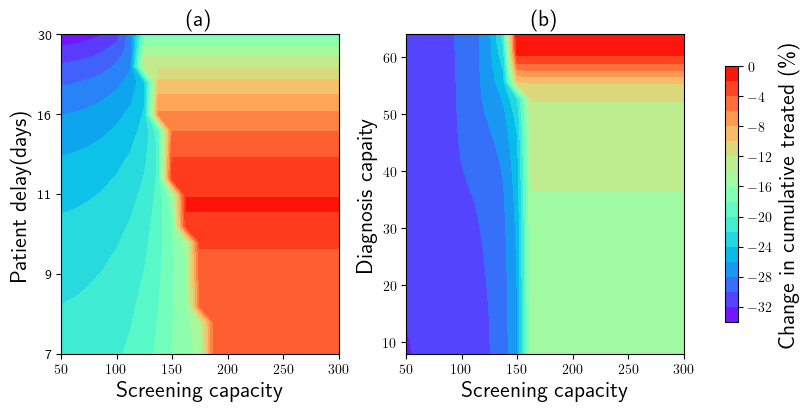

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(8, 4), constrained_layout=True)

cont1 = axs[0].contourf(X3, Y3, Z3, levels=20, cmap="rainbow")

axs[0].set_yticks(eta_0_values[::5])
axs[0].set_yticklabels(reciprocal_ticklabels(eta_0_values[::5]))

# invert to match desired orientation
axs[0].invert_yaxis()  # x: 7 days (right) → 30 days (left)

axs[0].set_title("(a)", fontsize = 16, fontweight = 'bold')
axs[0].set_ylabel("Patient delay(days)", fontsize = 16, fontweight = 'bold')
axs[0].set_xlabel("Screening capacity", fontsize = 16, fontweight = 'bold')

cont2 = axs[1].contourf(X4, Y4 ,Z4, levels=20, cmap="rainbow")

# axs[1].set_xticks(k_h_values[::4])
# axs[1].set_xticklabels(reciprocal_ticklabels(k_h_values[::4]))
#axs[1].invert_xaxis()  

#axs[1].set_yticks([])

axs[1].set_title("(b)", fontsize = 16, fontweight = 'bold')
axs[1].set_ylabel("Diagnosis capaity", fontsize = 16, fontweight = 'bold')
axs[1].set_xlabel("Screening capacity", fontsize = 16, fontweight = 'bold')

# shared colorbar
cbar = fig.colorbar(cont2, ax=axs, orientation="vertical", shrink=0.8)
cbar.set_label("Change in cumulative treated (\%)", fontsize = 16, fontweight = 'bold')

plt.show()